# Step 5 - DPIR feasibility and model loading

This notebook is the **first checkpoint** for Step 5 of the project plan: trying a recent method that was not part of the lecture methods.

We will use **DPIR**: *Plug-and-Play Image Restoration with Deep Denoiser Prior* by Zhang et al. The official implementation is here: <https://github.com/cszn/DPIR>.

**Important:** in this first notebook we do **not** run full deblurring yet. The goal is only to understand the idea, check the environment, find the DPIR code/model weights, load one project image, and load the DPIR model.

## Learning goals

By the end of this notebook you should be able to explain:

1. Why DPIR counts as a recent plug-and-play/deep-prior method.
2. What role the known blur operator plays.
3. What role the learned denoiser plays.
4. Whether your machine can import and load the DPIR model.


## 1. What does Step 5 ask for?

The project plan says that Step 5 should compare a **recent method** with the classical inverse-problem methods.

In our report language, we can describe DPIR like this:

> DPIR keeps the physical forward model of image degradation, but replaces a hand-designed regularizer with a deep CNN denoiser prior inside an iterative optimization scheme.

For deblurring, the forward model is still

$$
g = Af + \epsilon,
$$

where:

- $f$ is the unknown sharp image,
- $A$ is the known blur/convolution operator,
- $g$ is the observed blurred image,
- $\epsilon$ is noise.

**TODO for you:** Write one sentence in your own words: why is DPIR still an inverse-problem method and not just a black-box neural network? Its still the forward pass difference is just that it doesnt use handcrafted regularizer but a deep neural network denoiser.


## 2. DPIR idea: data term + learned denoiser prior

Classical regularized deblurring often solves something like

$$
\min_f \frac{1}{2}\|Af-g\|_2^2 + \lambda R(f),
$$

where $R(f)$ is a hand-designed prior, for example Tikhonov or TV.

DPIR is different:

- the **data step** uses the degradation model $Af \approx g$;
- the **prior step** uses a trained denoising network, DRUNet;
- the algorithm alternates these steps using a variable-splitting/HQS-style scheme.

This is called **plug-and-play** because the denoiser is plugged into an optimization algorithm as an implicit prior.

**Checkpoint question:** What information comes from the physics/model, and what information comes from data/training? Data term from physics model and prior term from training
 

In [2]:
# 3. Environment check
# Run this cell first. It should not depend on the external DPIR repository.

from __future__ import annotations

import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

try:
    import torch
except ImportError as exc:
    raise ImportError(
        "PyTorch is required for DPIR. Install it before continuing with model loading."
    ) from exc

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA GPU:", torch.cuda.get_device_name(0))
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Metal/MPS device")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU only - OK for loading the model, but full restoration may be slow.")


Python: 3.11.15
Platform: macOS-26.5.1-arm64-arm-64bit
NumPy: 2.4.3
PyTorch: 2.12.1
Using Apple Metal/MPS device


In [3]:
# 4. Project paths
# This cell assumes the notebook is in: project_root/src/step5_dpir_feasibility.ipynb
# If you move the notebook, adjust PROJECT_ROOT manually.

PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the src/ directory, go one level up.
if PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

# If the notebook is launched from somewhere else, this marker helps us find the repo root.
if not (PROJECT_ROOT / "AGENTS.md").exists():
    candidate = Path.cwd().resolve()
    for parent in [candidate, *candidate.parents]:
        if (parent / "AGENTS.md").exists() and (parent / "docs" / "project_plan.md").exists():
            PROJECT_ROOT = parent
            break

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("AGENTS.md found:", (PROJECT_ROOT / "AGENTS.md").exists())

DATA_CLEAN_DIR = PROJECT_ROOT / "data" / "processed" / "clean"
DATA_BLUR_NOISE_DIR = PROJECT_ROOT / "data" / "processed" / "blur+noise"
EXTERNAL_DIR = PROJECT_ROOT / "external"
DPIR_DIR = EXTERNAL_DIR / "DPIR"

print("Clean data dir:", DATA_CLEAN_DIR)
print("Blur+noise data dir:", DATA_BLUR_NOISE_DIR)
print("Expected DPIR dir:", DPIR_DIR)


Project root: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject
Project root exists: True
AGENTS.md found: True
Clean data dir: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/data/processed/clean
Blur+noise data dir: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/data/processed/blur+noise
Expected DPIR dir: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/external/DPIR


## 5. External DPIR repository setup

We intentionally keep DPIR outside the tracked source tree:

```text
external/DPIR/
```

The folder `external/` is ignored by Git, because it may contain:

- a full external repository,
- pretrained model weights,
- large downloaded files.

If `external/DPIR` is missing, run this in a terminal from the project root:

```bash
mkdir -p external
git clone https://github.com/cszn/DPIR.git external/DPIR
```

We are not running this automatically in the notebook so that you see exactly what is added locally.


In [4]:
# 6. Check whether DPIR exists locally

print("external/ exists:", EXTERNAL_DIR.exists())
print("external/DPIR exists:", DPIR_DIR.exists())

expected_files = [
    DPIR_DIR / "models" / "network_unet.py",
    DPIR_DIR / "models" / "basicblock.py",
    DPIR_DIR / "main_dpir_deblur.py",
    DPIR_DIR / "main_download_pretrained_models.py",
]

for path in expected_files:
    print(f"{path.relative_to(PROJECT_ROOT) if path.exists() else path}: {path.exists()}")

if not DPIR_DIR.exists():
    print("\nDPIR is not cloned yet. Stop here, clone it into external/DPIR, then rerun this cell.")


external/ exists: True
external/DPIR exists: True
external/DPIR/models/network_unet.py: True
external/DPIR/models/basicblock.py: True
external/DPIR/main_dpir_deblur.py: True
external/DPIR/main_download_pretrained_models.py: True


## 7. Model-weight check

DPIR uses pretrained DRUNet denoiser weights. For color images, the weight file we care about first is usually:

```text
external/DPIR/model_zoo/drunet_color.pth
```

Why color? Our landscape photos are RGB images.

The DPIR repository provides a download helper, but model hosting can change over time. If the automatic download fails, the report can still say that this was a setup limitation and we can fall back to a smaller plug-and-play variant later.

**TODO for you:** Before running model loading, check the size of the `.pth` file if it exists. Why should we avoid committing it?


In [6]:
# 8. Check for pretrained model weights

MODEL_NAME = "drunet_color"
MODEL_WEIGHTS = DPIR_DIR / "model_zoo" / f"{MODEL_NAME}.pth"

print("Expected model weights:", MODEL_WEIGHTS)
print("Weights exist:", MODEL_WEIGHTS.exists())

if MODEL_WEIGHTS.exists():
    size_mb = MODEL_WEIGHTS.stat().st_size / (1024**2)
    print(f"Weight file size: {size_mb:.1f} MB")
else:
    print("\nWeights are missing. After cloning DPIR, try one of these from the project root:")
    print("  cd external/DPIR")
    print('  python main_download_pretrained_models.py --models "DPIR" --model_dir "model_zoo"')
    print("\nFor this first checkpoint, missing weights are OK; the next cells will skip model loading.")


Expected model weights: /Users/giannigagliardi/localDocuments/gitLocal/Photodeblurring_IPProject/external/DPIR/model_zoo/drunet_color.pth
Weights exist: True
Weight file size: 124.5 MB


In [7]:
# 9. Load one clean image and one degraded image from our project
# We only inspect images here. Full DPIR deblurring comes later.

clean_candidates = sorted(DATA_CLEAN_DIR.glob("*.png"))
degraded_candidates = sorted(DATA_BLUR_NOISE_DIR.glob("*.png"))

print("Clean images found:", len(clean_candidates))
print("Degraded blur+noise images found:", len(degraded_candidates))

if not clean_candidates:
    raise FileNotFoundError(
        f"No clean PNG images found in {DATA_CLEAN_DIR}. Run scripts/prepare_images.py first."
    )

clean_path = clean_candidates[0]
degraded_path = degraded_candidates[0] if degraded_candidates else None

clean_img = Image.open(clean_path).convert("RGB")
clean_np = np.asarray(clean_img, dtype=np.float32) / 255.0

print("Clean image path:", clean_path.relative_to(PROJECT_ROOT))
print("Clean image shape:", clean_np.shape)
print("Clean image range:", float(clean_np.min()), "to", float(clean_np.max()))

if degraded_path is not None:
    degraded_img = Image.open(degraded_path).convert("RGB")
    degraded_np = np.asarray(degraded_img, dtype=np.float32) / 255.0
    print("Degraded image path:", degraded_path.relative_to(PROJECT_ROOT))
    print("Degraded image shape:", degraded_np.shape)
else:
    degraded_np = None
    print("No degraded image found yet. That is OK for model-loading feasibility.")

# TODO for you: print the dtype of clean_np and explain why we divide by 255.
# dividing in order to normalize
print(f"dtype clean_np: {type(clean_np)}")

Clean images found: 3
Degraded blur+noise images found: 9
Clean image path: data/processed/clean/1.png
Clean image shape: (512, 512, 3)
Clean image range: 0.0 to 0.9490196108818054
Degraded image path: data/processed/blur+noise/1_blur_noise0.02.png
Degraded image shape: (512, 512, 3)
dtype clean_np: <class 'numpy.ndarray'>


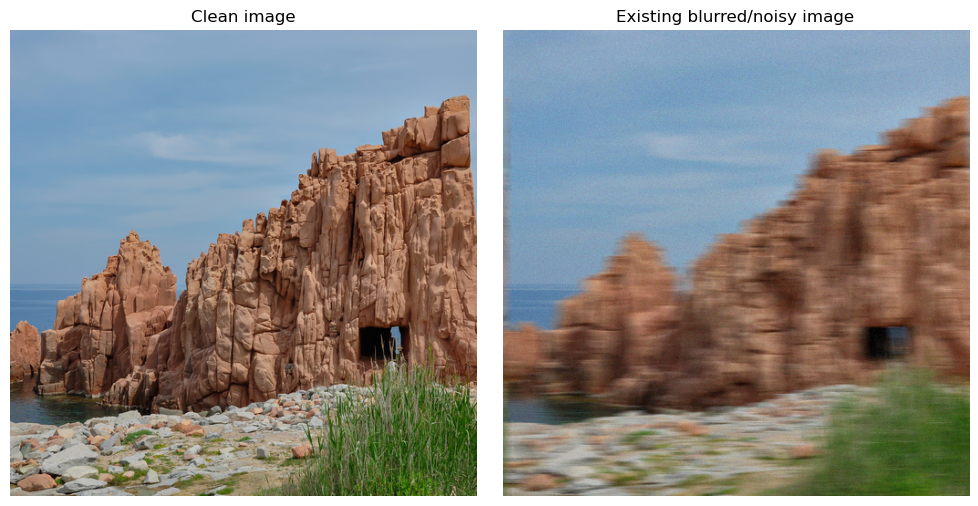

In [8]:
# 10. Visual sanity check

if degraded_np is None:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(clean_np)
    ax.set_title("Clean image")
    ax.axis("off")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(clean_np)
    axes[0].set_title("Clean image")
    axes[0].axis("off")

    axes[1].imshow(degraded_np)
    axes[1].set_title("Existing blurred/noisy image")
    axes[1].axis("off")

plt.tight_layout()
plt.show()


## 8. Load the DPIR model only

DPIR's color DRUNet usually uses the `UNetRes` class from `models/network_unet.py`.

For RGB denoising with a noise-level map, the input has 4 channels:

- 3 image channels: R, G, B
- 1 noise-level channel

The output has 3 channels: the restored RGB image.

So the model is created with:

```python
UNetRes(in_nc=4, out_nc=3, nc=[64, 128, 256, 512], nb=4, ...)
```

**Important:** We are only loading the model architecture and weights here. We are not yet running the HQS/DPIR deblurring iterations.


In [9]:
# 11. Import DPIR model code
# This cell is written to fail gently if DPIR is not cloned yet.

import importlib

dpir_ready = DPIR_DIR.exists() and (DPIR_DIR / "models" / "network_unet.py").exists()

if dpir_ready:
    # Add external/DPIR to sys.path so Python can import DPIR's internal modules.
    # We insert at the front so these imports are found before any unrelated package named "models".
    dpir_path_str = str(DPIR_DIR.resolve())
    if dpir_path_str not in sys.path:
        sys.path.insert(0, dpir_path_str)

    network_unet = importlib.import_module("models.network_unet")
    UNetRes = network_unet.UNetRes
    print("Imported UNetRes from DPIR successfully.")
else:
    UNetRes = None
    print("DPIR model code is not available yet. Clone DPIR into external/DPIR, then rerun this cell.")


Imported UNetRes from DPIR successfully.


In [10]:
# 12. Construct the DPIR/DRUNet model and load weights if available
# This is the main checkpoint for this notebook.

model = None

if UNetRes is None:
    print("Skipping model construction because DPIR code is missing.")
else:
    model = UNetRes(
        in_nc=4,              # RGB image (3) + noise-level map (1)
        out_nc=3,             # RGB output
        nc=[64, 128, 256, 512],
        nb=4,
        act_mode="R",
        downsample_mode="strideconv",
        upsample_mode="convtranspose",
    )

    if MODEL_WEIGHTS.exists():
        state_dict = torch.load(MODEL_WEIGHTS, map_location="cpu")
        model.load_state_dict(state_dict, strict=True)
        model.eval()
        model.to(DEVICE)
        print(f"Loaded {MODEL_NAME} weights successfully on {DEVICE}.")
    else:
        print("Constructed the model architecture, but weights are missing.")
        print("This is still useful: imports and architecture setup work.")

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Number of model parameters: {n_params:,}")


Loaded drunet_color weights successfully on mps.
Number of model parameters: 32,640,960


In [11]:
# 13. Optional mini forward-pass shape check
# Only run this if the model and weights loaded successfully.
# This is NOT deblurring. It only checks whether the network accepts a tensor shape.

if model is None or not MODEL_WEIGHTS.exists():
    print("Skipping forward-pass check because the loaded model is not available yet.")
else:
    with torch.no_grad():
        # Use a small crop to keep this quick.
        crop = clean_np[:64, :64, :]

        # Convert H x W x C image to N x C x H x W tensor.
        image_tensor = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0)

        # DPIR denoiser expects an extra noise-level channel.
        # Here 15/255 is just a small example denoising level, not yet tuned.
        noise_level = 15.0 / 255.0
        noise_map = torch.full(
            (1, 1, image_tensor.shape[-2], image_tensor.shape[-1]),
            fill_value=noise_level,
            dtype=image_tensor.dtype,
        )

        model_input = torch.cat([image_tensor, noise_map], dim=1).to(DEVICE)
        model_output = model(model_input).clamp(0, 1)

        print("Input tensor shape:", tuple(model_input.shape))
        print("Output tensor shape:", tuple(model_output.shape))
        print("If output is (1, 3, H, W), the DPIR denoiser forward pass works.")


Input tensor shape: (1, 4, 64, 64)
Output tensor shape: (1, 3, 64, 64)
If output is (1, 3, H, W), the DPIR denoiser forward pass works.


## Stop here: learning checkpoint

Do **not** continue to full restoration yet.

Before Step 5 continues, answer these in your own notes:

1. Did the environment use CPU, CUDA, or MPS?
2. Was `external/DPIR` found?
3. Were `drunet_color.pth` weights found?
4. Did the model architecture load?
5. If the forward-pass check ran, what were the input and output tensor shapes?
6. What is the difference between loading the denoiser and actually solving the deblurring inverse problem?

## Next session

The next notebook step should add one-image DPIR deblurring:

- use the same blur kernel as the generated data,
- run the DPIR/HQS iterations,
- save one restored output,
- compare visually with the blurred image,
- later compare against Step 3 and Step 4 methods.
